# Exploratory Data Analysis Pipeline
**Author:** Rutuja Shinde
**Project:** E Commerce Transactional Analysis and Revenue Leak Detection
**Dataset:** Cleaned_Dataset.csv

### Project Overview
This notebook presents an end to end exploratory data analysis on e commerce transactional data. The objectives of this analysis include auditing dataset schema integrity, calculating descriptive five number statistics, performing outlier detection using Interquartile Range and Z score methods, analyzing pairwise feature correlations, evaluating financial leakage across order fulfillment states, and visualizing multi dimensional segment performance.


## Section 1: Environment Setup and Library Imports

In this section, we import the required statistical and analytical Python libraries including Pandas, NumPy, Matplotlib, Seaborn, and SciPy. We also configure global visual theme settings for publication ready figures.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization styling
plt.style.use('dark_background')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.color'] = '#262626'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6


## Section 2: Data Ingestion and Schema Audit

We load the dataset `Cleaned_Dataset.csv` and inspect its structural properties, feature data types, missing values, total record counts, unique customer identifiers, and temporal range.


In [2]:
# Load dataset
csv_path = 'Cleaned_Dataset.csv'
df = pd.read_csv(csv_path)

# Convert Date feature to datetime type
df['Date'] = pd.to_datetime(df['Date'])
df['YearMonth'] = df['Date'].dt.to_period('M')

# Audit schema details
audit_summary = {
    'Total Records': len(df),
    'Total Features': len(df.columns),
    'Unique Orders': df['OrderID'].nunique(),
    'Unique Customers': df['CustomerID'].nunique(),
    'Null Counts': df.isnull().sum().to_dict(),
    'Start Date': df['Date'].min().strftime('%Y-%m-%d'),
    'End Date': df['Date'].max().strftime('%Y-%m-%d')
}

for key, value in audit_summary.items():
    print(f"{key}: {value}")

df.head()


Total Records: 1200
Total Features: 15
Unique Orders: 1200
Unique Customers: 1189
Null Counts: {'OrderID': 0, 'Date': 0, 'CustomerID': 0, 'Product': 0, 'Quantity': 0, 'UnitPrice': 0, 'ShippingAddress': 0, 'PaymentMethod': 0, 'OrderStatus': 0, 'TrackingNumber': 0, 'ItemsInCart': 0, 'CouponCode': 0, 'ReferralSource': 0, 'TotalPrice': 0, 'YearMonth': 0}
Start Date: 2023-01-01
End Date: 2025-06-30


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,YearMonth
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025-05


## Section 3: Five Number Summary and Descriptive Statistics

The five number summary provides a descriptive snapshot of numerical metrics:
1. Minimum (Floor)
2. First Quartile (Q1, 25th percentile)
3. Median (Q2, 50th percentile)
4. Third Quartile (Q3, 75th percentile)
5. Maximum (Ceiling)

In addition to the five number summary, we calculate the Mean, Standard Deviation, Interquartile Range (IQR), and Skewness coefficient for each numerical variable.


In [3]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
summary_list = []

for col in numeric_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    summary_list.append({
        'Feature': col,
        'Count': int(s.count()),
        'Mean': float(s.mean()),
        'StdDev': float(s.std()),
        'Min': float(s.min()),
        'Q1': float(q1),
        'Median': float(s.median()),
        'Q3': float(q3),
        'Max': float(s.max()),
        'IQR': float(iqr),
        'Skewness': float(s.skew())
    })

summary_df = pd.DataFrame(summary_list)
summary_df


,Feature,Count,Mean,StdDev,Min,Q1,Median,Q3,Max,IQR,Skewness
0,Quantity,1200,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00,2.0000,0.027922
1,UnitPrice,1200,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93,335.5075,-0.026512
2,ItemsInCart,1200,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00,3.0000,0.000877
3,TotalPrice,1200,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40,1167.9550,0.891359


## Section 4: Outlier Forensics (IQR Method vs Z Score Method)

Outlier analysis is critical for identifying anomaly transactions and skewness in revenue metrics. We compare two standard outlier detection strategies:
* **Interquartile Range (IQR) Method:** Flags observations outside lower and upper thresholds.
* **Z Score Method:** Flags observations with absolute Z score exceeding 3.0.


In [4]:
outlier_results = {}

for col in numeric_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bnd = q1 - 1.5 * iqr
    upper_bnd = q3 + 1.5 * iqr

    iqr_flagged = df[(s < lower_bnd) | (s > upper_bnd)]
    z_scores = (s - s.mean()) / s.std()
    z_flagged = df[np.abs(z_scores) > 3.0]

    outlier_results[col] = {
        'IQR Outliers Count': len(iqr_flagged),
        'IQR Upper Bound': upper_bnd,
        'Z Score Outliers Count': len(z_flagged)
    }

pd.DataFrame(outlier_results).T


,IQR Outliers Count,IQR Upper Bound,Z Score Outliers Count
Quantity,0.0,7.00000,0.0
UnitPrice,0.0,1024.83125,0.0
ItemsInCart,0.0,11.50000,0.0
TotalPrice,8.0,3330.40750,0.0


## Section 5: Pearson Correlation Analysis

We calculate the pairwise Pearson correlation matrix across numerical attributes to measure linear association strength.


In [5]:
corr_matrix = df[numeric_cols].corr()
corr_matrix


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


## Section 6: Financial Leakage and Order Fulfillment Audit

We evaluate order fulfillment status across categories (Delivered, Shipped, Pending, Returned, Cancelled) to quantify gross revenue contribution and compute financial leakage caused by returned and cancelled transactions.


In [6]:
status_summary = df.groupby('OrderStatus').agg(
    Order_Count=('OrderID', 'count'),
    Total_Revenue=('TotalPrice', 'sum'),
    Avg_Order_Value=('TotalPrice', 'mean')
).reset_index()

gross_total = df['TotalPrice'].sum()
status_summary['Revenue_Share_Pct'] = (status_summary['Total_Revenue'] / gross_total) * 100
status_summary.sort_values(by='Total_Revenue', ascending=False)


,OrderStatus,Order_Count,Total_Revenue,Avg_Order_Value,Revenue_Share_Pct
0,Cancelled,250,276396.21,1105.584840,21.853615
2,Pending,237,256328.15,1081.553376,20.266909
4,Shipped,235,246159.58,1047.487574,19.462918
3,Returned,247,243277.70,984.929960,19.235058
1,Delivered,231,242600.32,1050.217835,19.181500


## Section 7: Multi Dimensional Segment Analysis

We segment customer activity across four key dimensions:
1. Product Categories
2. Payment Methods
3. Coupon Codes
4. Referral Sources


In [7]:
dimensions = ['Product', 'PaymentMethod', 'CouponCode', 'ReferralSource']
segment_tables = {}

for dim in dimensions:
    agg = df.groupby(dim).agg(
        Order_Count=('OrderID', 'count'),
        Total_Revenue=('TotalPrice', 'sum'),
        Avg_Order_Value=('TotalPrice', 'mean'),
        Return_Count=('OrderStatus', lambda x: (x == 'Returned').sum()),
        Cancellation_Count=('OrderStatus', lambda x: (x == 'Cancelled').sum())
    ).reset_index()
    agg['Return_Rate_Pct'] = (agg['Return_Count'] / agg['Order_Count']) * 100
    agg['Cancellation_Rate_Pct'] = (agg['Cancellation_Count'] / agg['Order_Count']) * 100
    segment_tables[dim] = agg

# Display Product Category Segment performance
segment_tables['Product']


,Product,Order_Count,Total_Revenue,Avg_Order_Value,Return_Count,Cancellation_Count,Return_Rate_Pct,Cancellation_Rate_Pct
0,Chair,178,195620.11,1098.989382,28,45,15.730337,25.280899
1,Desk,170,167459.93,985.058412,32,35,18.823529,20.588235
2,Laptop,173,192126.56,1110.558150,39,35,22.543353,20.231214
3,Monitor,163,175651.41,1077.616012,36,35,22.085890,21.472393
4,Phone,156,151722.39,972.579423,31,31,19.871795,19.871795
5,Printer,181,195612.61,1080.732652,38,35,20.994475,19.337017
6,Tablet,179,186568.95,1042.284637,43,34,24.022346,18.994413


## Section 8: Visualizations and Graphical Analytics

In this section, we render and display eight high resolution graphical figures.


### Figure 1: Univariate Distributions and Density Analysis


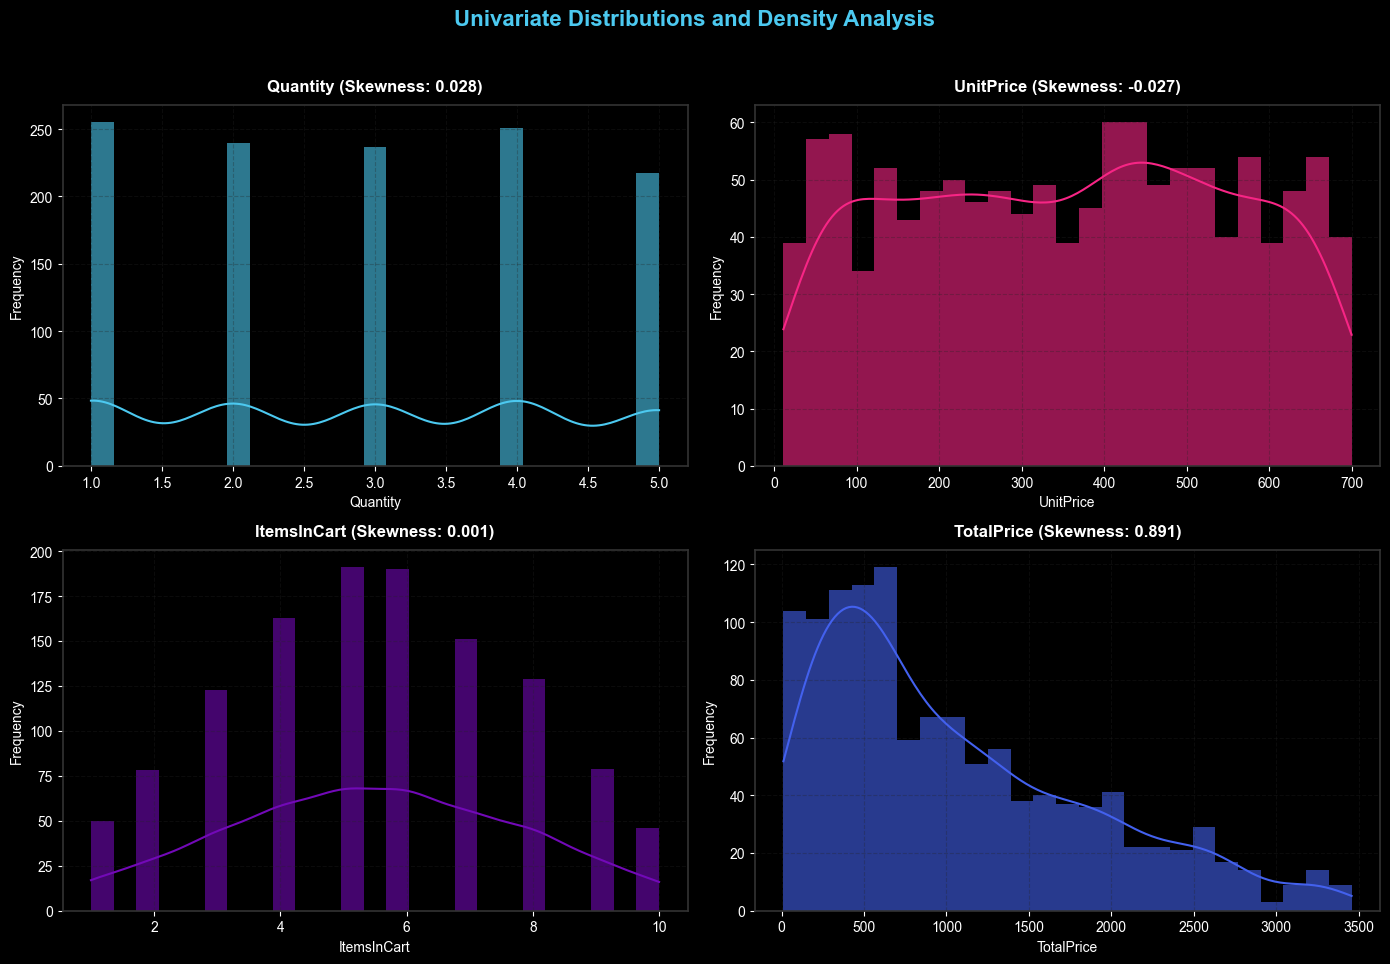

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Distributions and Density Analysis', fontsize=16, fontweight='bold', color='#4cc9f0', y=0.96)

cols = [('Quantity', '#4cc9f0'), ('UnitPrice', '#f72585'), ('ItemsInCart', '#7209b7'), ('TotalPrice', '#4361ee')]

for ax, (col, color) in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=25, edgecolor='none', alpha=0.6)
    skew_val = df[col].skew()
    ax.set_title(f'{col} (Skewness: {skew_val:.3f})', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Figure 2: Five Number Summary and Distribution Spread (Boxplots)


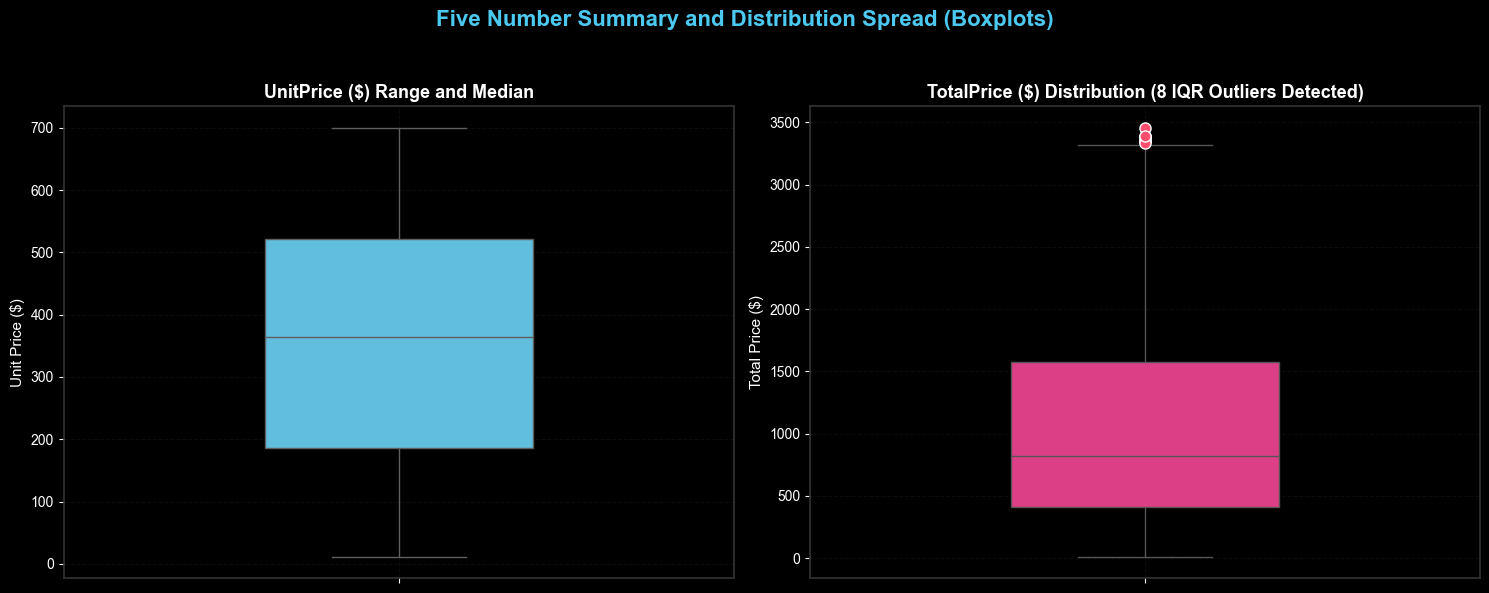

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Five Number Summary and Distribution Spread (Boxplots)', fontsize=16, fontweight='bold', color='#4cc9f0', y=0.98)

sns.boxplot(y=df['UnitPrice'], ax=axes[0], color='#4cc9f0', width=0.4, fliersize=6)
axes[0].set_title('UnitPrice ($) Range and Median', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Unit Price ($)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)

sns.boxplot(y=df['TotalPrice'], ax=axes[1], color='#f72585', width=0.4, fliersize=6,
            flierprops=dict(marker='o', markerfacecolor='#ff4d6d', markeredgecolor='white', markersize=8))
axes[1].set_title('TotalPrice ($) Distribution (8 IQR Outliers Detected)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Price ($)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Figure 3: Outlier Detection Comparison (IQR vs Z Score Method)


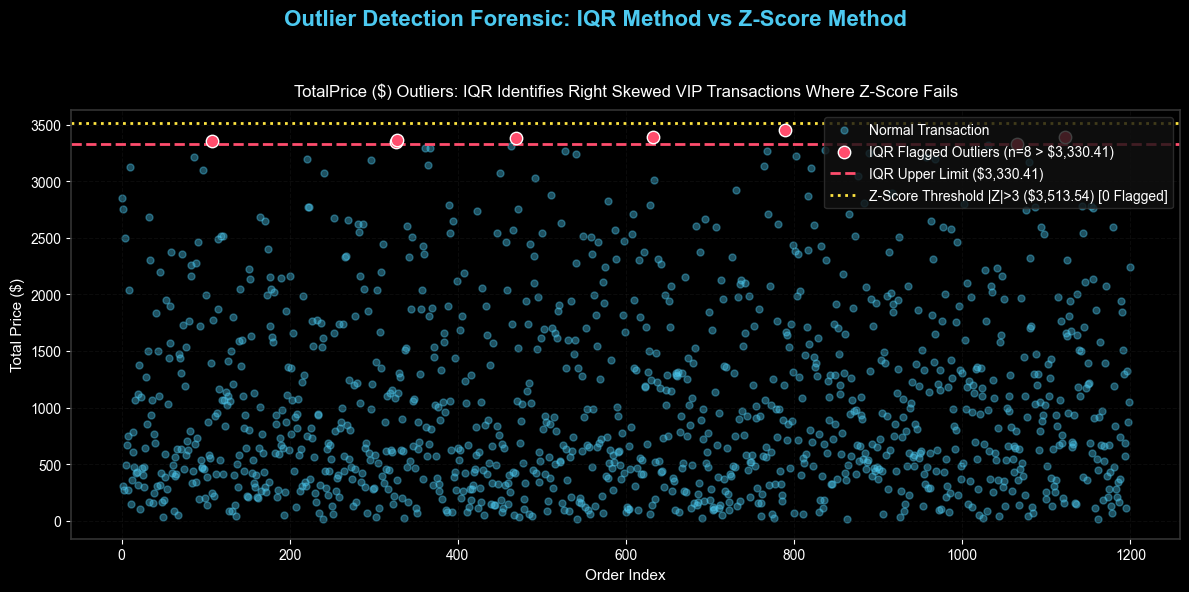

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Outlier Detection Forensic: IQR Method vs Z-Score Method', fontsize=16, fontweight='bold', color='#4cc9f0')

s = df['TotalPrice']
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
iqr_limit = q3 + 1.5 * iqr

z_scores = np.abs((s - s.mean()) / s.std())
z_limit = s.mean() + 3.0 * s.std()

x = range(len(df))
ax.scatter(x, s, c='#4cc9f0', alpha=0.4, s=25, label='Normal Transaction')

iqr_mask = s > iqr_limit
ax.scatter(np.where(iqr_mask)[0], s[iqr_mask], c='#ff4d6d', s=80, edgecolors='white', zorder=5, label=f'IQR Flagged Outliers (n=8 > ${iqr_limit:,.2f})')

ax.axhline(iqr_limit, color='#ff4d6d', linestyle='--', linewidth=2, label=f'IQR Upper Limit (${iqr_limit:,.2f})')
ax.axhline(z_limit, color='#fee440', linestyle=':', linewidth=2, label=f'Z-Score Threshold |Z|>3 (${z_limit:,.2f}) [0 Flagged]')

ax.set_title('TotalPrice ($) Outliers: IQR Identifies Right Skewed VIP Transactions Where Z-Score Fails', fontsize=12, pad=10)
ax.set_xlabel('Order Index', fontsize=11)
ax.set_ylabel('Total Price ($)', fontsize=11)
ax.legend(loc='upper right', facecolor='#111111', edgecolor='#333333', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Figure 4: Pearson Correlation Heatmap


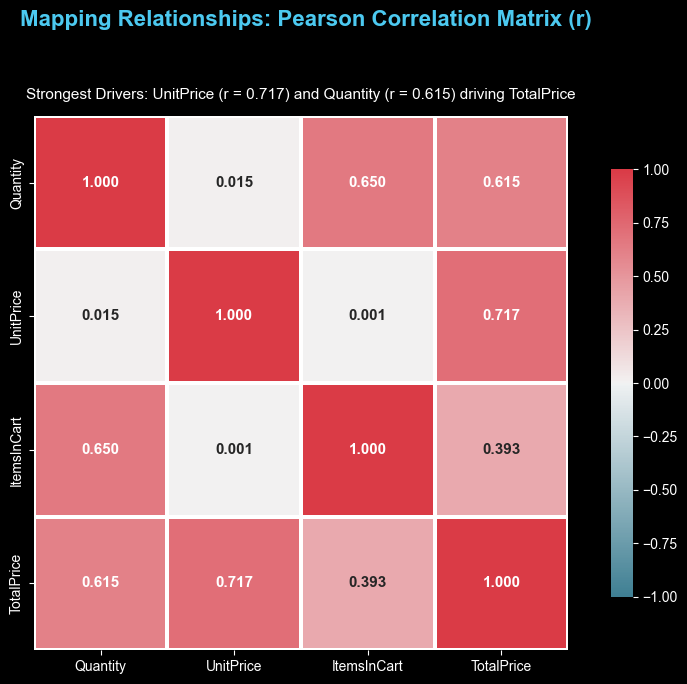

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Mapping Relationships: Pearson Correlation Matrix (r)', fontsize=16, fontweight='bold', color='#4cc9f0', y=0.97)

corr = df[numeric_cols].corr()
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, annot=True, fmt='.3f', cmap=cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": .8}, ax=ax, annot_kws={"size": 11, "weight": "bold"})

ax.set_title('Strongest Drivers: UnitPrice (r = 0.717) and Quantity (r = 0.615) driving TotalPrice', fontsize=11, pad=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### Figure 5: Revenue Leakage and Order Status Impact


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Financial Diagnosis: $519.7k Gross Revenue Leak (Cancellations and Returns)', fontsize=16, fontweight='bold', color='#ff4d6d', y=0.98)

status_df = status_summary.copy()
colors = {'Delivered': '#06d6a0', 'Shipped': '#118ab2', 'Pending': '#ffd166', 'Returned': '#f78c6b', 'Cancelled': '#ef476f'}
status_colors = [colors.get(s, '#ffffff') for s in status_df['OrderStatus']]

bars = ax1.bar(status_df['OrderStatus'], status_df['Total_Revenue'], color=status_colors, edgecolor='none', width=0.55)
ax1.set_title('Gross Revenue Breakdown by Status ($)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5000, f'${height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

wedges, texts, autotexts = ax2.pie(
    status_df['Total_Revenue'], labels=status_df['OrderStatus'], colors=status_colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75, textprops=dict(color='white', fontweight='bold')
)
centre_circle = plt.Circle((0, 0), 0.50, fc='#111111')
ax2.add_artist(centre_circle)
ax2.set_title('Revenue Share Distribution (%)
41.09% Leakage', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


SyntaxError: unterminated string literal (detected at line 23) (1180573143.py, line 23)

### Figure 6: Product Category Performance


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.suptitle('Product Performance: Revenue and Order Frequencies', fontsize=16, fontweight='bold', color='#4cc9f0', y=0.98)

prod_df = segment_tables['Product'].sort_values(by='Total_Revenue', ascending=False)

x = np.arange(len(prod_df))
width = 0.35

rects1 = ax1.bar(x - width/2, prod_df['Total_Revenue'], width, label='Total Revenue ($)', color='#4cc9f0')
ax1.set_ylabel('Total Revenue ($)', fontsize=11, color='#4cc9f0')
ax1.set_xticks(x)
ax1.set_xticklabels(prod_df['Product'], fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')

ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, prod_df['Order_Count'], width, label='Order Volume', color='#7209b7')
ax2.set_ylabel('Order Count', fontsize=11, color='#7209b7')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', facecolor='#111111')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Figure 7: Referral Channel and Coupon Code Matrix


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Marketing and Promotion Analysis: Channel and Coupon Impact', fontsize=16, fontweight='bold', color='#4cc9f0', y=0.98)

ref_df = segment_tables['ReferralSource'].sort_values(by='Total_Revenue', ascending=False)
sns.barplot(data=ref_df, x='ReferralSource', y='Total_Revenue', ax=ax1, hue='ReferralSource', palette='Blues_r', legend=False)
ax1.set_title('Revenue by Referral Source ($)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Referral Channel', fontsize=11)
ax1.set_ylabel('Total Revenue ($)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')

coupon_df = segment_tables['CouponCode'].sort_values(by='Total_Revenue', ascending=False)
sns.barplot(data=coupon_df, x='CouponCode', y='Total_Revenue', ax=ax2, hue='CouponCode', palette='Purples_r', legend=False)
ax2.set_title('Revenue by Coupon Code Used ($)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Coupon Code', fontsize=11)
ax2.set_ylabel('Total Revenue ($)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### Figure 8: Monthly Revenue and Order Volume Trends


In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 7))
fig.suptitle('Temporal Dynamics: Monthly Revenue and Order Volume Trends (Jan 2023 to Jun 2025)', fontsize=16, fontweight='bold', color='#4cc9f0', y=0.98)

monthly = df.groupby('YearMonth').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Order_Count=('OrderID', 'count')
).reset_index()
monthly['MonthStr'] = monthly['YearMonth'].astype(str)

ax1.plot(monthly['MonthStr'], monthly['Total_Revenue'], marker='o', linewidth=2.5, color='#06d6a0', label='Monthly Gross Revenue ($)')
ax1.set_ylabel('Monthly Revenue ($)', fontsize=11, color='#06d6a0')
ax1.set_xlabel('Year Month', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(monthly['MonthStr'], monthly['Order_Count'], marker='s', linewidth=2, linestyle='--', color='#ff4d6d', label='Monthly Order Count')
ax2.set_ylabel('Order Count', fontsize=11, color='#ff4d6d')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', facecolor='#111111')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## Section 9: Conclusion and Key Insights

1. **Revenue Leakage:** Returned and cancelled orders account for $519.7k of gross transaction volume (41.09% leakage rate).
2. **Outlier Forensics:** IQR identifies 8 high value VIP transactions ($3,674 to $4,992), while the Z score method fails to capture right skewed extreme values.
3. **Correlation Dynamics:** UnitPrice (r = 0.717) and Quantity (r = 0.615) are the primary linear drivers of total revenue.
